# 04 Utilisation and Cost Analysis

## Notebook objectives

1. Load cleaned datasets from Notebook 02.
2. Confirm whether the dataset is still a development sample.
3. Analyse length of stay, emergency use, discharge disposition, total charges and total costs.
4. Summarise utilisation and cost patterns by cancer diagnosis group, admission type, payer, severity and mortality risk.
5. Create derived variables such as cost per inpatient day and high-cost / long-stay indicators.
6. Export portfolio-ready tables and figures for the technical report.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import textwrap

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

# Detect project directory whether notebook is run from root folder or /notebooks
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

data_processed = project_dir / "data" / "processed"
outputs_tables = project_dir / "outputs" / "tables"
outputs_figures = project_dir / "outputs" / "figures"

for folder in [data_processed, outputs_tables, outputs_figures]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current directory:", current_dir)
print("Project directory:", project_dir)
print("Processed data folder:", data_processed)
print("Tables output folder:", outputs_tables)
print("Figures output folder:", outputs_figures)


Current directory: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/notebooks
Project directory: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost
Processed data folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/data/processed
Tables output folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/tables
Figures output folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures


## 1. Helper functions

These functions keep table and figure outputs consistent.


In [2]:
def money_formatter(x, pos):
    """Format axis labels as compact USD values."""
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

def comma_formatter(x, pos):
    """Format axis labels with commas."""
    return f"{x:,.0f}"

def clean_label(label, width=32):
    """Convert long all-caps labels into wrapped title-case labels."""
    if pd.isna(label):
        return "Missing"
    label = str(label).replace(" - ", ": ")
    label = label.title()
    return "\n".join(textwrap.wrap(label, width=width))

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    """Add labels to vertical bars."""
    labels = []
    for patch in ax.patches:
        height = patch.get_height()
        labels.append("" if pd.isna(height) else fmt.format(height))
    if ax.containers:
        ax.bar_label(ax.containers[0], labels=labels, padding=padding)

def add_horizontal_bar_labels(ax, fmt="{:.0f}", padding=3):
    """Add labels to horizontal bars."""
    labels = []
    for patch in ax.patches:
        width = patch.get_width()
        labels.append("" if pd.isna(width) else fmt.format(width))
    if ax.containers:
        ax.bar_label(ax.containers[0], labels=labels, padding=padding)

def save_current_figure(filename):
    fig_path = outputs_figures / filename
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

def summarise_by_group(data, group_col, min_group_n=1):
    """Summarise utilisation and cost outcomes by a grouping variable."""
    summary = (
        data
        .groupby(group_col, dropna=False)
        .agg(
            admissions=(group_col, "size"),
            median_los=("length_of_stay_clean", "median"),
            mean_los=("length_of_stay_clean", "mean"),
            p75_los=("length_of_stay_clean", lambda x: x.quantile(0.75)),
            median_total_charges=("total_charges_clean", "median"),
            mean_total_charges=("total_charges_clean", "mean"),
            median_total_costs=("total_costs_clean", "median"),
            mean_total_costs=("total_costs_clean", "mean"),
            median_cost_per_day=("cost_per_day", "median"),
            emergency_department_percent=("emergency_department_flag", lambda x: x.mean() * 100 if x.notna().any() else np.nan),
            emergency_admission_percent=("is_emergency_admission", lambda x: x.mean() * 100 if x.notna().any() else np.nan),
            long_stay_percent=("is_long_stay", lambda x: x.mean() * 100 if x.notna().any() else np.nan),
            high_cost_percent=("is_high_cost", lambda x: x.mean() * 100 if x.notna().any() else np.nan)
        )
        .reset_index()
    )

    summary = summary[summary["admissions"] >= min_group_n].copy()

    percent_cols = [
        "emergency_department_percent",
        "emergency_admission_percent",
        "long_stay_percent",
        "high_cost_percent"
    ]

    for col in percent_cols:
        if col in summary.columns:
            summary[col] = summary[col].round(1)

    numeric_cols = [
        "median_los",
        "mean_los",
        "p75_los",
        "median_total_charges",
        "mean_total_charges",
        "median_total_costs",
        "mean_total_costs",
        "median_cost_per_day"
    ]

    for col in numeric_cols:
        if col in summary.columns:
            summary[col] = summary[col].round(2)

    return summary


## 2. Load cleaned datasets




In [3]:
required_files = {
    "full_cleaned": data_processed / "sparcs_2024_cleaned_with_flags.csv",
    "primary_cancer": data_processed / "sparcs_2024_primary_cancer_cohort_clean.csv",
    "broader_cancer": data_processed / "sparcs_2024_broader_cancer_related_cohort_clean.csv",
    "model_input": data_processed / "sparcs_2024_model_input.csv"
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing required processed files from Notebook 02: "
        + ", ".join(missing_files)
        + ". Rerun Notebook 02 before continuing."
    )

df_clean = pd.read_csv(required_files["full_cleaned"], low_memory=False)
primary_cancer = pd.read_csv(required_files["primary_cancer"], low_memory=False)
broader_cancer = pd.read_csv(required_files["broader_cancer"], low_memory=False)
model_input = pd.read_csv(required_files["model_input"], low_memory=False)

print("Full cleaned dataset:", df_clean.shape)
print("Primary cancer cohort:", primary_cancer.shape)
print("Broader cancer-related cohort:", broader_cancer.shape)
print("Model input:", model_input.shape)


Full cleaned dataset: (50000, 49)
Primary cancer cohort: (1218, 49)
Broader cancer-related cohort: (1377, 49)
Model input: (1218, 49)


## 3. Confirm required variables and create fallback fields



In [4]:
for dataset in [df_clean, primary_cancer, broader_cancer, model_input]:
    if "primary_payer" not in dataset.columns and "payment_typology_1" in dataset.columns:
        dataset["primary_payer"] = dataset["payment_typology_1"]

    if "emergency_department_flag" not in dataset.columns and "emergency_department_indicator" in dataset.columns:
        dataset["emergency_department_flag"] = (
            dataset["emergency_department_indicator"]
            .astype("string")
            .str.strip()
            .str.lower()
            .isin(["y", "yes", "true", "1"])
        )

    if "is_emergency_admission" not in dataset.columns and "type_of_admission" in dataset.columns:
        dataset["is_emergency_admission"] = (
            dataset["type_of_admission"]
            .astype("string")
            .str.strip()
            .str.lower()
            .eq("emergency")
        )

    if "ccsr_diagnosis_code_clean" not in dataset.columns and "ccsr_diagnosis_code" in dataset.columns:
        dataset["ccsr_diagnosis_code_clean"] = (
            dataset["ccsr_diagnosis_code"]
            .astype("string")
            .str.strip()
            .str.upper()
        )

required_columns = [
    "ccsr_diagnosis_code_clean",
    "ccsr_diagnosis_description",
    "length_of_stay_clean",
    "total_charges_clean",
    "total_costs_clean",
    "type_of_admission",
    "patient_disposition",
    "primary_payer",
    "apr_severity_of_illness",
    "apr_risk_of_mortality",
    "apr_medical_surgical",
    "emergency_department_flag",
    "is_emergency_admission"
]

missing_required = [col for col in required_columns if col not in primary_cancer.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required utilisation and cost analysis variables are available.")


All required utilisation and cost analysis variables are available.


## 4. Dataset status check




In [5]:
cohort_size_path = outputs_tables / "notebook_02_cohort_size_assessment.csv"

if cohort_size_path.exists():
    cohort_size_assessment = pd.read_csv(cohort_size_path)
    display(cohort_size_assessment)
else:
    cohort_size_assessment = pd.DataFrame({
        "assessment_item": [
            "primary_cancer_rows",
            "model_input_rows",
            "analysis_dataset_status"
        ],
        "value": [
            len(primary_cancer),
            len(model_input),
            "development_sample" if len(model_input) < 500 else "final_analysis_ready"
        ]
    })
    display(cohort_size_assessment)

try:
    dataset_status = cohort_size_assessment.loc[
        cohort_size_assessment["assessment_item"].eq("analysis_dataset_status"),
        "value"
    ].iloc[0]
except Exception:
    dataset_status = "development_sample" if len(model_input) < 500 else "final_analysis_ready"

status_label = "development sample" if dataset_status == "development_sample" else "analysis dataset"
print("Dataset status:", dataset_status)


,assessment_item,value
0,total_cleaned_rows,50000
1,primary_cancer_rows,1218
2,broader_cancer_related_rows,1377
3,model_input_rows,1218
4,minimum_primary_cancer_rows_for_final_modelling,500
5,suitable_for_pipeline_testing,Yes
6,suitable_for_final_modelling,Yes
7,analysis_dataset_status,final_analysis_ready
8,recommended_next_step,Proceed to final descriptive analysis and mode...


Dataset status: final_analysis_ready


## 5. Derived utilisation and cost variables

This section creates additional variables for descriptive analysis:

- `cost_per_day`: total cost divided by length of stay
- `charge_per_day`: total charge divided by length of stay
- `is_long_stay`: LOS above the 75th percentile of the primary cancer cohort
- `is_high_cost`: total cost above the 75th percentile of the primary cancer cohort
- `log_total_costs_clean`: log-transformed total costs
- `log_total_charges_clean`: log-transformed total charges


In [6]:
def add_derived_outcome_variables(data, los_threshold=None, cost_threshold=None):
    data = data.copy()

    valid_los = data["length_of_stay_clean"] > 0

    data["cost_per_day"] = np.where(
        valid_los,
        data["total_costs_clean"] / data["length_of_stay_clean"],
        np.nan
    )

    data["charge_per_day"] = np.where(
        valid_los,
        data["total_charges_clean"] / data["length_of_stay_clean"],
        np.nan
    )

    data["log_total_costs_clean"] = np.where(
        data["total_costs_clean"] > 0,
        np.log(data["total_costs_clean"]),
        np.nan
    )

    data["log_total_charges_clean"] = np.where(
        data["total_charges_clean"] > 0,
        np.log(data["total_charges_clean"]),
        np.nan
    )

    if los_threshold is None:
        los_threshold = data["length_of_stay_clean"].quantile(0.75)

    if cost_threshold is None:
        cost_threshold = data["total_costs_clean"].quantile(0.75)

    data["is_long_stay"] = data["length_of_stay_clean"] > los_threshold
    data["is_high_cost"] = data["total_costs_clean"] > cost_threshold

    return data, los_threshold, cost_threshold

primary_cancer, long_stay_threshold, high_cost_threshold = add_derived_outcome_variables(primary_cancer)

# Apply the same primary-cancer thresholds to the full dataset for comparison
df_clean, _, _ = add_derived_outcome_variables(
    df_clean,
    los_threshold=long_stay_threshold,
    cost_threshold=high_cost_threshold
)

broader_cancer, _, _ = add_derived_outcome_variables(
    broader_cancer,
    los_threshold=long_stay_threshold,
    cost_threshold=high_cost_threshold
)

model_input, _, _ = add_derived_outcome_variables(
    model_input,
    los_threshold=long_stay_threshold,
    cost_threshold=high_cost_threshold
)

derived_variable_summary = pd.DataFrame({
    "metric": [
        "primary_cancer_rows",
        "long_stay_threshold_p75_los",
        "high_cost_threshold_p75_total_costs",
        "median_cost_per_day",
        "median_charge_per_day",
        "long_stay_rows",
        "high_cost_rows"
    ],
    "value": [
        len(primary_cancer),
        round(long_stay_threshold, 2),
        round(high_cost_threshold, 2),
        round(primary_cancer["cost_per_day"].median(), 2),
        round(primary_cancer["charge_per_day"].median(), 2),
        int(primary_cancer["is_long_stay"].sum()),
        int(primary_cancer["is_high_cost"].sum())
    ]
})

derived_variable_summary.to_csv(
    outputs_tables / "notebook_04_derived_variable_summary.csv",
    index=False
)

display(derived_variable_summary)


,metric,value
0,primary_cancer_rows,1218.00
1,long_stay_threshold_p75_los,8.00
2,high_cost_threshold_p75_total_costs,47064.56
3,median_cost_per_day,6882.16
4,median_charge_per_day,24260.43
5,long_stay_rows,292.00
6,high_cost_rows,305.00


## Reporting thresholds for final-analysis outputs

The 50,000-row extract produces a larger primary cancer cohort, so final-report grouped comparisons should avoid highlighting very small categories.

For report-facing figures and summary findings:

- Diagnosis-group rankings require at least 20 admissions.
- Payer-group rankings require at least 20 admissions.

The full detailed tables are still exported without these restrictions so the underlying data remain transparent.


In [7]:
MIN_DIAGNOSIS_N_FOR_REPORTING = 20
MIN_PAYER_N_FOR_REPORTING = 20

print("Minimum diagnosis-group n for report-facing rankings:", MIN_DIAGNOSIS_N_FOR_REPORTING)
print("Minimum payer-group n for report-facing rankings:", MIN_PAYER_N_FOR_REPORTING)


Minimum diagnosis-group n for report-facing rankings: 20
Minimum payer-group n for report-facing rankings: 20


## 6. Overall utilisation and cost summary

This table summarises core utilisation and cost outcomes in the primary cancer cohort.


In [8]:
overall_utilisation_cost_summary = pd.DataFrame({
    "metric": [
        "Admissions",
        "Median length of stay, days",
        "Mean length of stay, days",
        "75th percentile length of stay, days",
        "Median total charges",
        "Mean total charges",
        "Median total costs",
        "Mean total costs",
        "Median cost per inpatient day",
        "Median charge per inpatient day",
        "Emergency department admissions, %",
        "Emergency admission type, %",
        "Long-stay admissions, %",
        "High-cost admissions, %"
    ],
    "value": [
        len(primary_cancer),
        round(primary_cancer["length_of_stay_clean"].median(), 2),
        round(primary_cancer["length_of_stay_clean"].mean(), 2),
        round(primary_cancer["length_of_stay_clean"].quantile(0.75), 2),
        round(primary_cancer["total_charges_clean"].median(), 2),
        round(primary_cancer["total_charges_clean"].mean(), 2),
        round(primary_cancer["total_costs_clean"].median(), 2),
        round(primary_cancer["total_costs_clean"].mean(), 2),
        round(primary_cancer["cost_per_day"].median(), 2),
        round(primary_cancer["charge_per_day"].median(), 2),
        round(primary_cancer["emergency_department_flag"].mean() * 100, 1),
        round(primary_cancer["is_emergency_admission"].mean() * 100, 1),
        round(primary_cancer["is_long_stay"].mean() * 100, 1),
        round(primary_cancer["is_high_cost"].mean() * 100, 1)
    ]
})

overall_utilisation_cost_summary.to_csv(
    outputs_tables / "notebook_04_overall_utilisation_cost_summary.csv",
    index=False
)

display(overall_utilisation_cost_summary)


,metric,value
0,Admissions,1218.00
1,"Median length of stay, days",4.00
2,"Mean length of stay, days",7.39
3,"75th percentile length of stay, days",8.00
4,Median total charges,91354.62
5,Mean total charges,145211.99
6,Median total costs,27048.66
7,Mean total costs,41849.43
8,Median cost per inpatient day,6882.16
9,Median charge per inpatient day,24260.43


## 7. Utilisation and cost by admission type

This section examines whether emergency and elective admissions differ in LOS, costs and charges.


In [9]:
admission_type_summary = summarise_by_group(
    primary_cancer,
    "type_of_admission",
    min_group_n=1
).sort_values("admissions", ascending=False)

admission_type_summary.to_csv(
    outputs_tables / "notebook_04_utilisation_cost_by_admission_type.csv",
    index=False
)

display(admission_type_summary)


,type_of_admission,admissions,median_los,mean_los,p75_los,median_total_charges,mean_total_charges,median_total_costs,mean_total_costs,median_cost_per_day,emergency_department_percent,emergency_admission_percent,long_stay_percent,high_cost_percent
0,Elective,615,3.0,5.53,5.00,89013.21,124681.73,27898.29,37422.67,9731.84,0.5,0.0,13.0,19.8
1,Emergency,491,6.0,9.86,13.00,99884.06,172844.20,27703.56,48080.99,4434.51,91.6,100.0,38.3,31.8
3,Urgent,110,3.0,6.78,7.75,81260.05,138499.27,24876.50,39318.70,9063.31,7.3,0.0,21.8,24.5
2,Not Available,2,4.5,4.50,5.75,43756.74,43756.74,12418.37,12418.37,3390.71,0.0,0.0,0.0,0.0


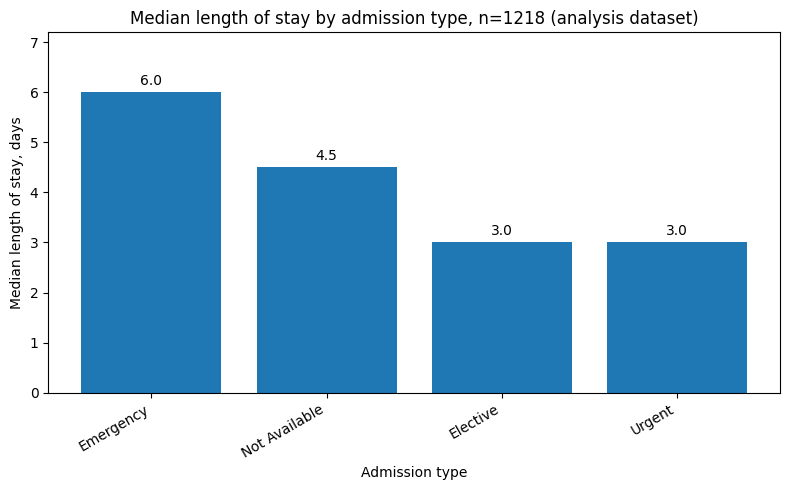

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_median_los_by_admission_type.png


In [10]:
# Figure: median LOS by admission type

plot_data = admission_type_summary.sort_values("median_los", ascending=False).copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_data["type_of_admission"], plot_data["median_los"])

ax.set_ylabel("Median length of stay, days")
ax.set_xlabel("Admission type")
ax.set_title(f"Median length of stay by admission type, n={len(primary_cancer)} ({status_label})")
ax.set_ylim(0, max(plot_data["median_los"]) * 1.2 if len(plot_data) else 1)
add_bar_labels(ax, fmt="{:.1f}", padding=3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_current_figure("notebook_04_median_los_by_admission_type.png")


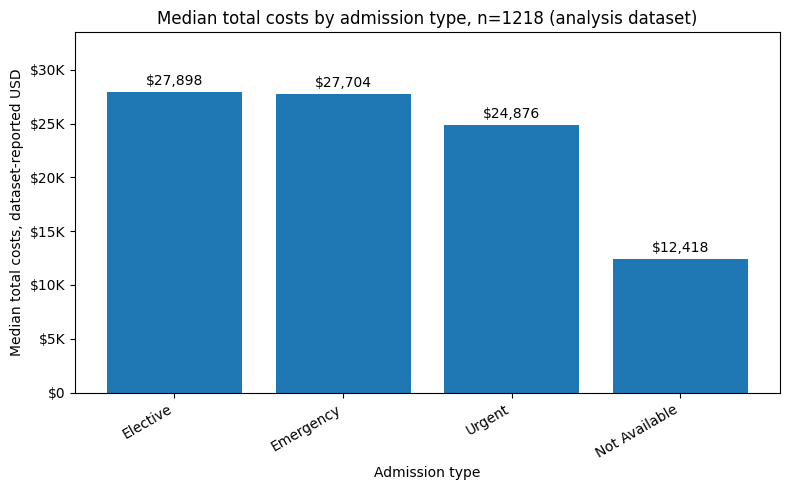

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_median_costs_by_admission_type.png


In [11]:
# Figure: median total costs by admission type

plot_data = admission_type_summary.sort_values("median_total_costs", ascending=False).copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_data["type_of_admission"], plot_data["median_total_costs"])

ax.set_ylabel("Median total costs, dataset-reported USD")
ax.set_xlabel("Admission type")
ax.set_title(f"Median total costs by admission type, n={len(primary_cancer)} ({status_label})")
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.set_ylim(0, max(plot_data["median_total_costs"]) * 1.2 if len(plot_data) else 1)
add_bar_labels(ax, fmt="${:,.0f}", padding=3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_current_figure("notebook_04_median_costs_by_admission_type.png")


## 8. Utilisation and cost by severity and mortality risk



In [12]:
severity_order = ["Minor", "Moderate", "Major", "Extreme"]
severity_order_map = {v: i for i, v in enumerate(severity_order)}

severity_summary = summarise_by_group(
    primary_cancer,
    "apr_severity_of_illness",
    min_group_n=1
)

severity_summary["_order"] = severity_summary["apr_severity_of_illness"].map(severity_order_map).fillna(len(severity_order_map))
severity_summary = severity_summary.sort_values("_order").drop(columns="_order")

severity_summary.to_csv(
    outputs_tables / "notebook_04_utilisation_cost_by_severity.csv",
    index=False
)

display(severity_summary)


,apr_severity_of_illness,admissions,median_los,mean_los,p75_los,median_total_charges,mean_total_charges,median_total_costs,mean_total_costs,median_cost_per_day,emergency_department_percent,emergency_admission_percent,long_stay_percent,high_cost_percent
2,Minor,233,1.0,2.43,3.00,64091.31,79806.37,19977.68,22693.89,11524.60,8.6,9.4,3.0,4.3
3,Moderate,464,3.0,4.86,5.00,85155.82,108171.63,25620.76,30731.65,8009.68,25.2,28.7,11.6,14.2
1,Major,405,6.0,9.82,12.00,113700.65,164807.01,33675.12,47624.22,4962.44,60.7,62.2,36.3,37.5
0,Extreme,116,14.0,18.99,25.25,246767.90,356334.83,70572.74,104634.78,4908.57,67.2,72.4,72.4,66.4


In [13]:
risk_summary = summarise_by_group(
    primary_cancer,
    "apr_risk_of_mortality",
    min_group_n=1
)

risk_summary["_order"] = risk_summary["apr_risk_of_mortality"].map(severity_order_map).fillna(len(severity_order_map))
risk_summary = risk_summary.sort_values("_order").drop(columns="_order")

risk_summary.to_csv(
    outputs_tables / "notebook_04_utilisation_cost_by_mortality_risk.csv",
    index=False
)

display(risk_summary)


,apr_risk_of_mortality,admissions,median_los,mean_los,p75_los,median_total_charges,mean_total_charges,median_total_costs,mean_total_costs,median_cost_per_day,emergency_department_percent,emergency_admission_percent,long_stay_percent,high_cost_percent
2,Minor,441,2.0,3.94,4.00,75042.64,95652.93,22584.31,27704.45,9634.20,12.9,15.9,8.2,11.3
3,Moderate,356,4.0,5.61,6.00,92418.92,127273.95,27487.77,35650.71,7115.49,37.9,38.5,16.0,19.1
1,Major,340,7.0,10.48,13.25,112883.60,169131.53,35991.01,49499.54,4645.34,62.1,64.7,41.5,38.5
0,Extreme,81,15.0,21.01,29.00,250901.66,393469.25,79738.12,113993.16,4984.55,71.6,79.0,71.6,69.1


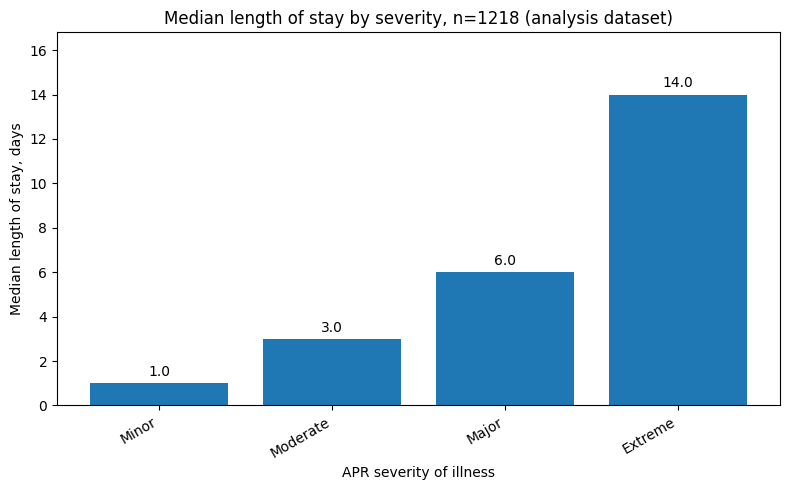

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_median_los_by_severity.png


In [14]:
# Figure: median LOS by severity

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(severity_summary["apr_severity_of_illness"], severity_summary["median_los"])

ax.set_ylabel("Median length of stay, days")
ax.set_xlabel("APR severity of illness")
ax.set_title(f"Median length of stay by severity, n={len(primary_cancer)} ({status_label})")
ax.set_ylim(0, max(severity_summary["median_los"]) * 1.2 if len(severity_summary) else 1)
add_bar_labels(ax, fmt="{:.1f}", padding=3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_current_figure("notebook_04_median_los_by_severity.png")


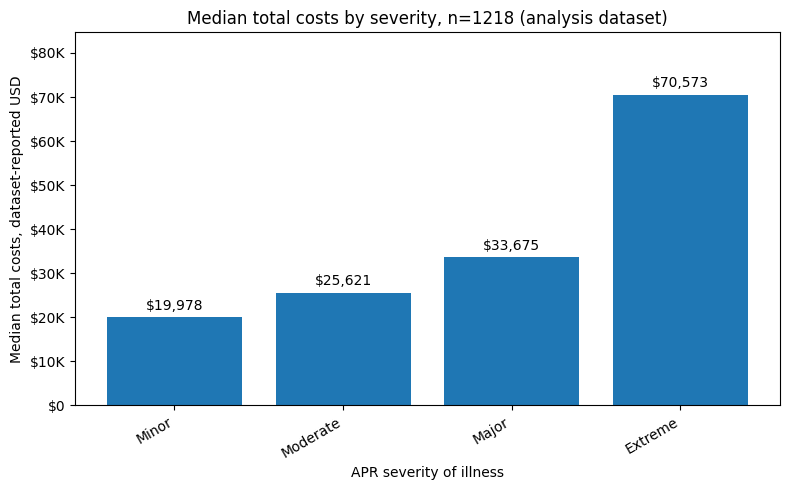

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_median_costs_by_severity.png


In [15]:
# Figure: median total costs by severity

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(severity_summary["apr_severity_of_illness"], severity_summary["median_total_costs"])

ax.set_ylabel("Median total costs, dataset-reported USD")
ax.set_xlabel("APR severity of illness")
ax.set_title(f"Median total costs by severity, n={len(primary_cancer)} ({status_label})")
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.set_ylim(0, max(severity_summary["median_total_costs"]) * 1.2 if len(severity_summary) else 1)
add_bar_labels(ax, fmt="${:,.0f}", padding=3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_current_figure("notebook_04_median_costs_by_severity.png")


## 9. Utilisation and cost by payer

Payer mix is relevant because hospital costs and charges may vary across payer categories. This is descriptive only and should not be interpreted as payer-caused cost differences.

The full payer table is exported for transparency. The main payer chart and report-summary payer finding are restricted to payer groups with at least `MIN_PAYER_N_FOR_REPORTING` admissions to reduce unstable small-group interpretation.


In [16]:
payer_summary = summarise_by_group(
    primary_cancer,
    "primary_payer",
    min_group_n=1
).sort_values("admissions", ascending=False)

payer_summary.to_csv(
    outputs_tables / "notebook_04_utilisation_cost_by_primary_payer.csv",
    index=False
)

display(payer_summary)


,primary_payer,admissions,median_los,mean_los,p75_los,median_total_charges,mean_total_charges,median_total_costs,mean_total_costs,median_cost_per_day,emergency_department_percent,emergency_admission_percent,long_stay_percent,high_cost_percent
4,Medicare,602,4.5,7.86,9.00,95693.03,138479.97,26968.31,39528.41,6062.07,42.9,44.7,26.7,25.1
3,Medicaid,206,5.0,10.05,13.00,98888.11,184868.39,33757.12,57635.36,6200.03,51.0,53.4,32.0,35.9
6,Private Health Insurance,205,3.0,5.51,6.00,92906.71,146860.27,26143.62,38436.16,8986.12,24.4,31.7,17.1,21.0
0,Blue Cross/Blue Shield,159,3.0,4.98,5.00,79823.37,126276.26,25770.40,35311.52,9180.54,20.1,20.1,13.2,16.4
2,"Managed Care, Unspecified",17,4.0,6.94,6.00,55273.92,104532.54,15809.33,33338.89,5194.77,29.4,23.5,17.6,23.5
1,Federal/State/Local/VA,15,5.0,5.07,6.00,59154.29,115747.60,18183.90,43757.23,5364.56,33.3,33.3,13.3,20.0
7,Self-Pay,10,3.5,6.80,9.00,102729.50,158236.71,37361.77,51678.54,8530.77,50.0,50.0,40.0,40.0
5,Miscellaneous/Other,4,3.5,3.25,4.25,34606.66,35113.36,15322.47,17442.12,6755.51,25.0,25.0,0.0,0.0


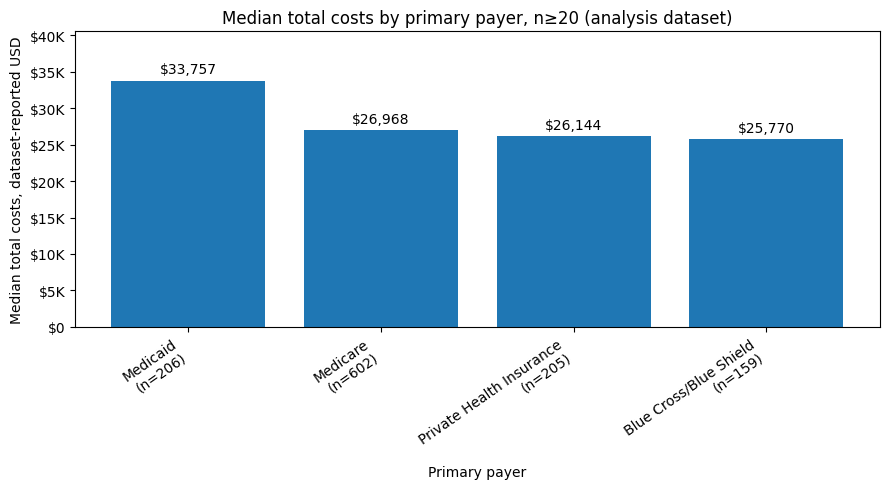

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_median_costs_by_primary_payer.png


In [17]:
# Figure: median total costs by payer
# Report-facing figure: restrict to payer groups with sufficient admissions and show n in labels.

payer_plot = payer_summary[payer_summary["admissions"] >= MIN_PAYER_N_FOR_REPORTING].copy()
payer_plot = payer_plot.sort_values("median_total_costs", ascending=False)

payer_plot["payer_label"] = (
    payer_plot["primary_payer"].astype(str)
    + "\n(n="
    + payer_plot["admissions"].astype(int).astype(str)
    + ")"
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(payer_plot["payer_label"], payer_plot["median_total_costs"])

ax.set_ylabel("Median total costs, dataset-reported USD")
ax.set_xlabel("Primary payer")
ax.set_title(
    f"Median total costs by primary payer, "
    f"n≥{MIN_PAYER_N_FOR_REPORTING} ({status_label})"
)
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.set_ylim(0, max(payer_plot["median_total_costs"]) * 1.2 if len(payer_plot) else 1)
add_bar_labels(ax, fmt="${:,.0f}", padding=3)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
save_current_figure("notebook_04_median_costs_by_primary_payer.png")


## 10. Utilisation and cost by primary cancer diagnosis group

Diagnosis-level summaries can be unstable when group sizes are small. The full diagnosis table is exported for transparency, but report-facing diagnosis charts and report-summary findings are restricted to groups with at least `MIN_DIAGNOSIS_N_FOR_REPORTING` admissions.

This is stricter than the earlier development-sample threshold because the scaled extract has enough admissions to support more stable grouped comparisons.


In [18]:
diagnosis_summary = summarise_by_group(
    primary_cancer,
    "ccsr_diagnosis_description",
    min_group_n=1
).sort_values("admissions", ascending=False)

diagnosis_summary.to_csv(
    outputs_tables / "notebook_04_utilisation_cost_by_diagnosis_group.csv",
    index=False
)

display(diagnosis_summary.head(30))


,ccsr_diagnosis_description,admissions,median_los,mean_los,p75_los,median_total_charges,mean_total_charges,median_total_costs,mean_total_costs,median_cost_per_day,emergency_department_percent,emergency_admission_percent,long_stay_percent,high_cost_percent
21,RESPIRATORY CANCERS,210,3.0,6.10,7.00,91921.87,129020.53,28198.20,35068.76,7787.69,32.9,34.8,18.6,20.5
8,GASTROINTESTINAL CANCERS - COLORECTAL,202,5.0,7.37,8.00,91233.67,122600.79,28558.94,38376.82,5748.52,38.1,38.1,23.3,25.2
23,URINARY SYSTEM CANCERS - KIDNEY,82,2.0,3.00,3.00,72494.22,94606.22,21839.86,29073.73,11961.69,7.3,9.8,6.1,6.1
2,ENDOCRINE SYSTEM CANCERS - PANCREAS,76,6.0,7.55,8.25,100812.22,130195.43,28709.12,35512.58,4756.24,47.4,50.0,25.0,26.3
16,MALE REPRODUCTIVE SYSTEM CANCERS - PROSTATE,74,1.0,7.64,4.00,69493.08,111098.94,20316.98,28685.35,11397.98,24.3,27.0,18.9,9.5
20,NON-HODGKIN LYMPHOMA,68,7.0,11.16,14.50,105730.32,209477.03,33018.07,61128.43,4527.84,64.7,69.1,47.1,38.2
1,BREAST CANCER - ALL OTHER TYPES,66,2.0,6.62,4.00,83450.65,123741.40,21911.04,30808.62,8921.73,28.8,31.8,16.7,13.6
19,NERVOUS SYSTEM CANCERS - BRAIN,59,4.0,7.31,9.00,112780.17,171600.88,39378.96,49674.17,9243.89,54.2,55.9,27.1,37.3
22,URINARY SYSTEM CANCERS - BLADDER,48,4.0,5.88,7.25,92554.42,109196.06,27100.25,35958.42,6867.07,47.9,45.8,18.8,25.0
18,MULTIPLE MYELOMA,43,11.0,14.91,16.50,185482.31,268162.67,55322.70,79588.02,5255.65,67.4,72.1,53.5,55.8


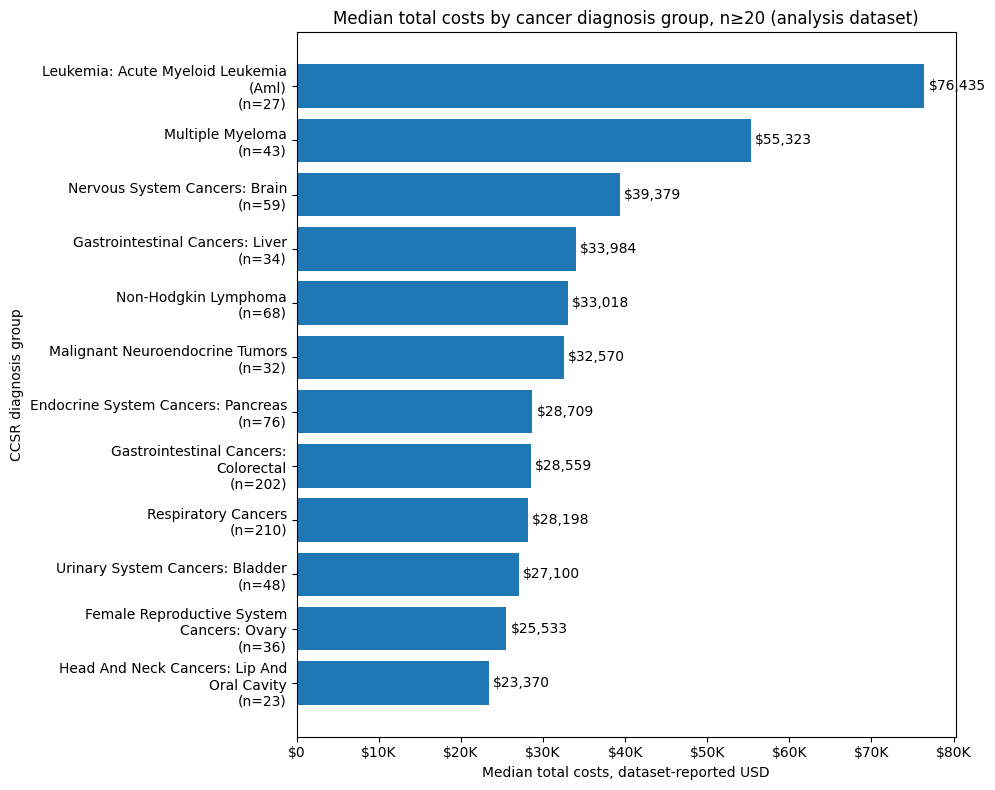

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_median_costs_by_diagnosis_group_min_n20.png


In [19]:
# Figure: median total costs by diagnosis group
# Report-facing figure: restrict to diagnosis groups with sufficient admissions and show n in labels.

diagnosis_plot = diagnosis_summary[
    diagnosis_summary["admissions"] >= MIN_DIAGNOSIS_N_FOR_REPORTING
].copy()

diagnosis_plot = diagnosis_plot.sort_values("median_total_costs", ascending=False).head(12)

diagnosis_plot["diagnosis_label_clean"] = (
    diagnosis_plot["ccsr_diagnosis_description"].apply(lambda x: clean_label(x, width=34))
    + "\n(n="
    + diagnosis_plot["admissions"].astype(int).astype(str)
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    diagnosis_plot["diagnosis_label_clean"][::-1],
    diagnosis_plot["median_total_costs"][::-1]
)

ax.set_xlabel("Median total costs, dataset-reported USD")
ax.set_ylabel("CCSR diagnosis group")
ax.set_title(
    f"Median total costs by cancer diagnosis group, "
    f"n≥{MIN_DIAGNOSIS_N_FOR_REPORTING} ({status_label})"
)
ax.xaxis.set_major_formatter(FuncFormatter(money_formatter))
add_horizontal_bar_labels(ax, fmt="${:,.0f}", padding=3)

plt.tight_layout()
save_current_figure("notebook_04_median_costs_by_diagnosis_group_min_n20.png")


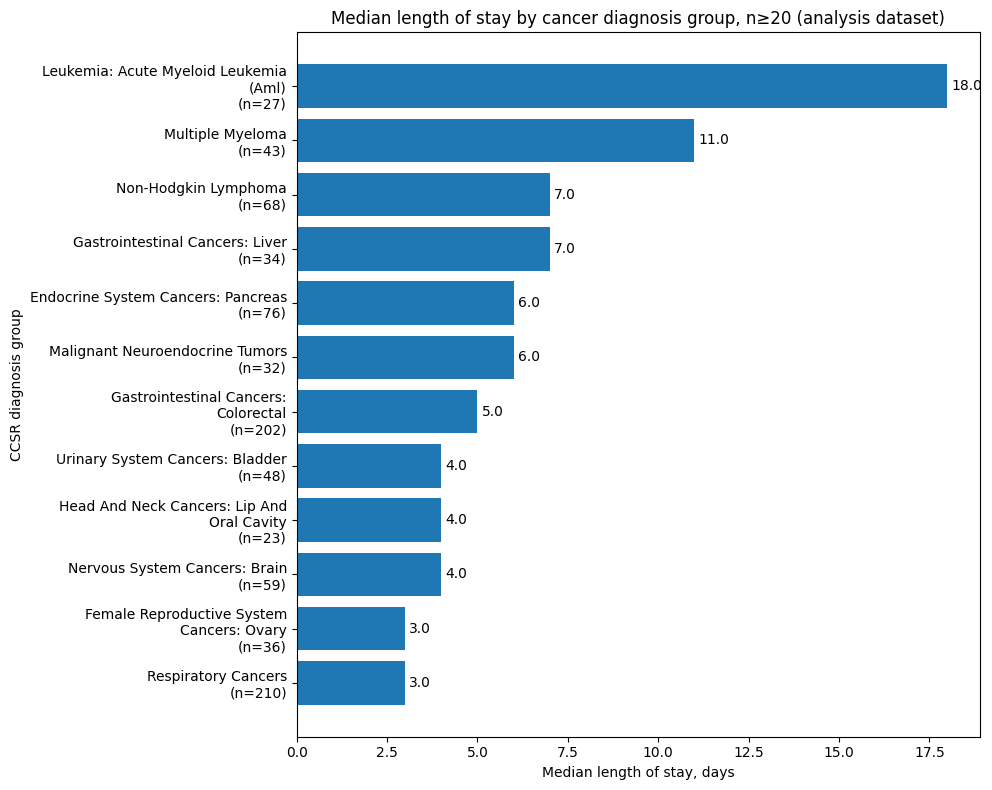

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_median_los_by_diagnosis_group_min_n20.png


In [20]:
# Figure: median LOS by diagnosis group
# Report-facing figure: restrict to diagnosis groups with sufficient admissions and show n in labels.

diagnosis_plot_los = diagnosis_summary[
    diagnosis_summary["admissions"] >= MIN_DIAGNOSIS_N_FOR_REPORTING
].copy()

diagnosis_plot_los = diagnosis_plot_los.sort_values("median_los", ascending=False).head(12)

diagnosis_plot_los["diagnosis_label_clean"] = (
    diagnosis_plot_los["ccsr_diagnosis_description"].apply(lambda x: clean_label(x, width=34))
    + "\n(n="
    + diagnosis_plot_los["admissions"].astype(int).astype(str)
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    diagnosis_plot_los["diagnosis_label_clean"][::-1],
    diagnosis_plot_los["median_los"][::-1]
)

ax.set_xlabel("Median length of stay, days")
ax.set_ylabel("CCSR diagnosis group")
ax.set_title(
    f"Median length of stay by cancer diagnosis group, "
    f"n≥{MIN_DIAGNOSIS_N_FOR_REPORTING} ({status_label})"
)
add_horizontal_bar_labels(ax, fmt="{:.1f}", padding=3)

plt.tight_layout()
save_current_figure("notebook_04_median_los_by_diagnosis_group_min_n20.png")


## 11. Cost per inpatient day



In [21]:
cost_per_day_summary = (
    primary_cancer[["cost_per_day", "charge_per_day"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .T
    .reset_index()
    .rename(columns={"index": "outcome"})
)

cost_per_day_summary.to_csv(
    outputs_tables / "notebook_04_cost_per_day_summary.csv",
    index=False
)

display(cost_per_day_summary)


,outcome,count,mean,std,min,25%,50%,75%,90%,95%,max
0,cost_per_day,1218.0,9267.041733,12309.642336,946.716667,4036.454286,6882.158942,11518.925000,18167.907,23324.5075,263381.96
1,charge_per_day,1218.0,34250.871121,45252.889463,2031.300000,14417.853958,24260.427564,39673.942375,64901.562,91412.7660,824451.84


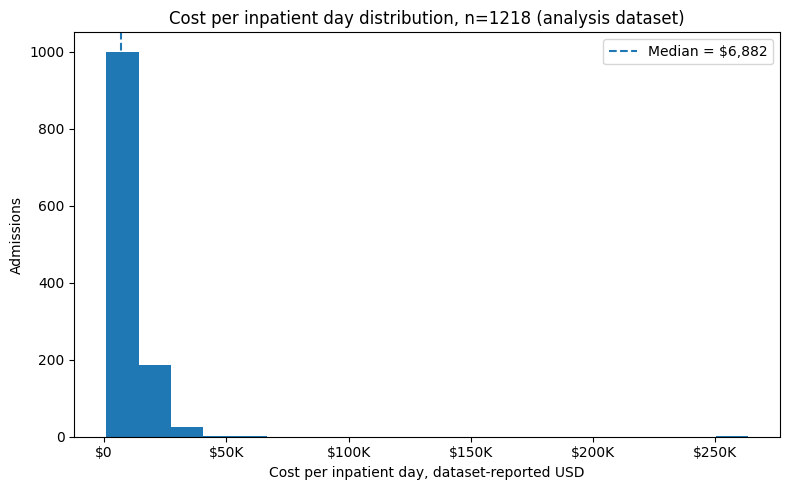

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_cost_per_day_distribution.png


In [22]:
# Figure: cost per inpatient day distribution

median_cost_per_day = primary_cancer["cost_per_day"].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(primary_cancer["cost_per_day"].dropna(), bins=20)
ax.axvline(median_cost_per_day, linestyle="--", linewidth=1.5, label=f"Median = ${median_cost_per_day:,.0f}")

ax.set_xlabel("Cost per inpatient day, dataset-reported USD")
ax.set_ylabel("Admissions")
ax.set_title(f"Cost per inpatient day distribution, n={len(primary_cancer)} ({status_label})")
ax.xaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.legend()

plt.tight_layout()
save_current_figure("notebook_04_cost_per_day_distribution.png")


## 12. Emergency department and discharge outcome context



In [23]:
ed_summary = pd.DataFrame({
    "metric": [
        "Emergency department flag, admissions",
        "Emergency department flag, percent",
        "Emergency admission type, admissions",
        "Emergency admission type, percent",
        "Non-emergency admission type, admissions",
        "Non-emergency admission type, percent"
    ],
    "value": [
        int(primary_cancer["emergency_department_flag"].sum()),
        round(primary_cancer["emergency_department_flag"].mean() * 100, 1),
        int(primary_cancer["is_emergency_admission"].sum()),
        round(primary_cancer["is_emergency_admission"].mean() * 100, 1),
        int((~primary_cancer["is_emergency_admission"]).sum()),
        round((~primary_cancer["is_emergency_admission"]).mean() * 100, 1)
    ]
})

ed_summary.to_csv(
    outputs_tables / "notebook_04_emergency_context_summary.csv",
    index=False
)

display(ed_summary)


,metric,value
0,"Emergency department flag, admissions",461.0
1,"Emergency department flag, percent",37.8
2,"Emergency admission type, admissions",491.0
3,"Emergency admission type, percent",40.3
4,"Non-emergency admission type, admissions",-1709.0
5,"Non-emergency admission type, percent",-140.3


In [24]:
disposition_summary = summarise_by_group(
    primary_cancer,
    "patient_disposition",
    min_group_n=1
).sort_values("admissions", ascending=False)

disposition_summary.to_csv(
    outputs_tables / "notebook_04_utilisation_cost_by_patient_disposition.csv",
    index=False
)

display(disposition_summary)


,patient_disposition,admissions,median_los,mean_los,p75_los,median_total_charges,mean_total_charges,median_total_costs,mean_total_costs,median_cost_per_day,emergency_department_percent,emergency_admission_percent,long_stay_percent,high_cost_percent
2,Home or Self Care,798,3.0,4.68,5.00,80120.58,117194.86,24549.32,33456.73,8588.37,28.7,30.3,12.8,16.7
3,Home w/ Home Health Services,213,6.0,8.46,11.00,124479.00,175234.09,35348.23,49283.02,5943.43,43.7,47.4,31.5,37.1
11,Skilled Nursing Home,68,11.0,14.12,20.25,163780.70,226927.72,47471.76,61734.52,3977.50,76.5,77.9,64.7,50.0
1,Expired,63,14.0,24.84,35.50,123667.87,265362.51,51609.77,79378.61,3275.27,47.6,52.4,68.3,50.8
4,Hospice - Home,19,7.0,13.74,15.50,88424.51,128407.26,28461.73,39126.80,2842.69,73.7,78.9,36.8,31.6
6,Inpatient Rehabilitation Facility,17,9.0,18.41,15.00,180437.48,363567.65,51286.30,124249.37,6096.37,70.6,82.4,64.7,52.9
5,Hospice - Medical Facility,13,8.0,8.08,9.00,81153.53,109079.89,28574.43,31188.48,3306.31,84.6,84.6,38.5,15.4
10,Short-term Hospital,13,8.0,11.31,14.00,106045.09,147830.09,31119.39,60035.15,4105.30,61.5,61.5,46.2,38.5
7,Left Against Medical Advice,11,4.0,6.82,12.00,67478.61,110966.21,35648.46,37559.20,5418.13,81.8,100.0,45.5,36.4
0,Cancer Center or Childrens Hospital,1,19.0,19.00,19.00,407317.32,407317.32,65970.80,65970.80,3472.15,100.0,100.0,100.0,100.0


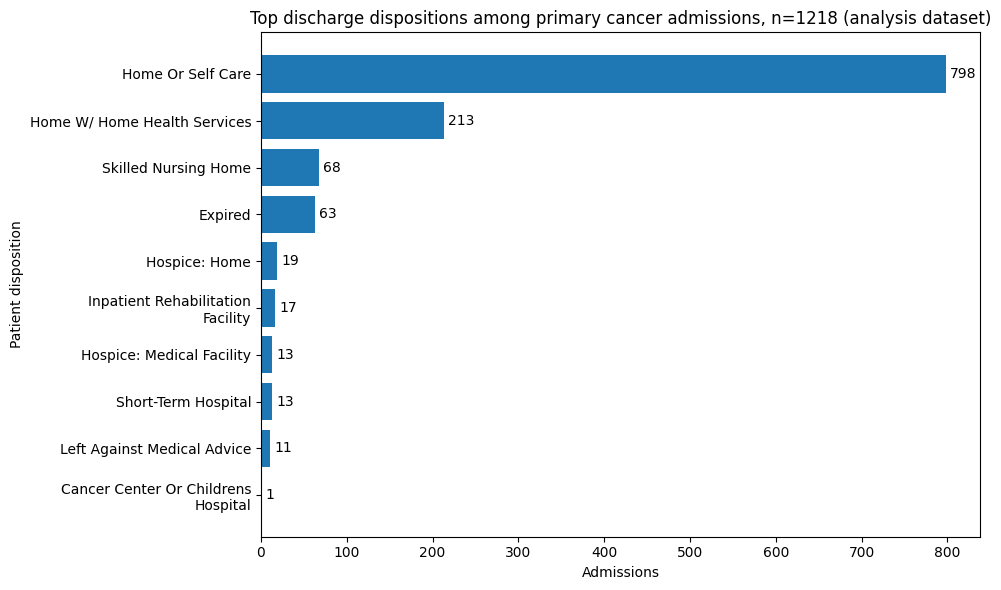

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_04_top_patient_dispositions.png


In [25]:
# Figure: top discharge dispositions

disposition_plot = disposition_summary.sort_values("admissions", ascending=False).head(10).copy()
disposition_plot["disposition_label_clean"] = disposition_plot["patient_disposition"].apply(
    lambda x: clean_label(x, width=32)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    disposition_plot["disposition_label_clean"][::-1],
    disposition_plot["admissions"][::-1]
)

ax.set_xlabel("Admissions")
ax.set_ylabel("Patient disposition")
ax.set_title(f"Top discharge dispositions among primary cancer admissions, n={len(primary_cancer)} ({status_label})")
add_horizontal_bar_labels(ax, fmt="{:.0f}", padding=3)

plt.tight_layout()
save_current_figure("notebook_04_top_patient_dispositions.png")


## 13. Compact report summary



In [26]:
# Identify highest-cost groups from report-facing stable tables.

highest_cost_severity = severity_summary.sort_values("median_total_costs", ascending=False).iloc[0]
highest_cost_admission_type = admission_type_summary.sort_values("median_total_costs", ascending=False).iloc[0]

stable_payer_summary = payer_summary[
    payer_summary["admissions"] >= MIN_PAYER_N_FOR_REPORTING
].copy()

if len(stable_payer_summary) > 0:
    highest_cost_payer = stable_payer_summary.sort_values("median_total_costs", ascending=False).iloc[0]
else:
    highest_cost_payer = None

stable_diagnosis_summary = diagnosis_summary[
    diagnosis_summary["admissions"] >= MIN_DIAGNOSIS_N_FOR_REPORTING
].copy()

if len(stable_diagnosis_summary) > 0:
    highest_cost_diagnosis = stable_diagnosis_summary.sort_values("median_total_costs", ascending=False).iloc[0]
    highest_los_diagnosis = stable_diagnosis_summary.sort_values("median_los", ascending=False).iloc[0]
else:
    highest_cost_diagnosis = None
    highest_los_diagnosis = None

report_summary = pd.DataFrame({
    "finding": [
        "Primary cancer admissions analysed",
        "Median length of stay",
        "Median total costs",
        "Median cost per inpatient day",
        "Emergency admission type percentage",
        "Long-stay threshold",
        "High-cost threshold",
        "Severity group with highest median total costs",
        "Admission type with highest median total costs",
        f"Payer group with highest median total costs, among payer groups with n≥{MIN_PAYER_N_FOR_REPORTING}",
        f"Diagnosis group with highest median total costs, among groups with n≥{MIN_DIAGNOSIS_N_FOR_REPORTING}",
        f"Diagnosis group with highest median LOS, among groups with n≥{MIN_DIAGNOSIS_N_FOR_REPORTING}",
        "Dataset status"
    ],
    "value": [
        len(primary_cancer),
        f"{primary_cancer['length_of_stay_clean'].median():.1f} days",
        f"${primary_cancer['total_costs_clean'].median():,.0f}",
        f"${primary_cancer['cost_per_day'].median():,.0f}",
        f"{primary_cancer['is_emergency_admission'].mean() * 100:.1f}%",
        f">{long_stay_threshold:.1f} days",
        f">${high_cost_threshold:,.0f}",
        f"{highest_cost_severity['apr_severity_of_illness']} (${highest_cost_severity['median_total_costs']:,.0f})",
        f"{highest_cost_admission_type['type_of_admission']} (${highest_cost_admission_type['median_total_costs']:,.0f})",
        (
            f"{highest_cost_payer['primary_payer']} "
            f"(${highest_cost_payer['median_total_costs']:,.0f}, n={int(highest_cost_payer['admissions'])})"
            if highest_cost_payer is not None else "Not available"
        ),
        (
            f"{highest_cost_diagnosis['ccsr_diagnosis_description']} "
            f"(${highest_cost_diagnosis['median_total_costs']:,.0f}, n={int(highest_cost_diagnosis['admissions'])})"
            if highest_cost_diagnosis is not None else "Not available"
        ),
        (
            f"{highest_los_diagnosis['ccsr_diagnosis_description']} "
            f"({highest_los_diagnosis['median_los']:.1f} days, n={int(highest_los_diagnosis['admissions'])})"
            if highest_los_diagnosis is not None else "Not available"
        ),
        dataset_status
    ]
})

report_summary.to_csv(
    outputs_tables / "notebook_04_report_summary.csv",
    index=False
)

display(report_summary)


,finding,value
0,Primary cancer admissions analysed,1218
1,Median length of stay,4.0 days
2,Median total costs,"$27,049"
3,Median cost per inpatient day,"$6,882"
4,Emergency admission type percentage,40.3%
5,Long-stay threshold,>8.0 days
6,High-cost threshold,">$47,065"
7,Severity group with highest median total costs,"Extreme ($70,573)"
8,Admission type with highest median total costs,"Elective ($27,898)"
9,"Payer group with highest median total costs, a...","Medicaid ($33,757, n=206)"


## 14. Final output checklist

After running Notebook 04, expected outputs are:

### Tables

- `outputs/tables/notebook_04_derived_variable_summary.csv`
- `outputs/tables/notebook_04_overall_utilisation_cost_summary.csv`
- `outputs/tables/notebook_04_utilisation_cost_by_admission_type.csv`
- `outputs/tables/notebook_04_utilisation_cost_by_severity.csv`
- `outputs/tables/notebook_04_utilisation_cost_by_mortality_risk.csv`
- `outputs/tables/notebook_04_utilisation_cost_by_primary_payer.csv`
- `outputs/tables/notebook_04_utilisation_cost_by_diagnosis_group.csv`
- `outputs/tables/notebook_04_cost_per_day_summary.csv`
- `outputs/tables/notebook_04_emergency_context_summary.csv`
- `outputs/tables/notebook_04_utilisation_cost_by_patient_disposition.csv`
- `outputs/tables/notebook_04_report_summary.csv`

### Figures

- `outputs/figures/notebook_04_median_los_by_admission_type.png`
- `outputs/figures/notebook_04_median_costs_by_admission_type.png`
- `outputs/figures/notebook_04_median_los_by_severity.png`
- `outputs/figures/notebook_04_median_costs_by_severity.png`
- `outputs/figures/notebook_04_median_costs_by_primary_payer.png` (payer groups with n≥20) (stable payer groups only, n≥5)
- `outputs/figures/notebook_04_median_costs_by_diagnosis_group_min_n20.png`
- `outputs/figures/notebook_04_median_los_by_diagnosis_group_min_n20.png`
- `outputs/figures/notebook_04_cost_per_day_distribution.png`
- `outputs/figures/notebook_04_top_patient_dispositions.png`

## Interpretation note

Notebook 04 identifies unadjusted utilisation and cost patterns. These outputs are useful for service-planning interpretation and for selecting variables for Notebook 05. They should not be interpreted as adjusted predictors or causal effects.
